# Homework assignment 2

**Deadline:** 16 March 2026
<br><br>
**Student names:**: A. Agung Prawira Negara & Nand Van Deun  ← **PLEASE REPLACE**
<br>
**Total hours spend:** 48 h
<br><br>
**Important Remarks:**
<br>
* **Submitting the homework is a compulsory course component. You will not be able to participate in the exam without submitting your homework solutions before the specified deadline.** 
* Making mistakes or not always being able to completely solve an exercise is fine. The goal is to let you interactively explore the concepts from the lecture and identify common problems/misconceptions. If you could not solve/finish a task, please discuss why using markdown cells.
* If you should have any questions please don't hesitate to ask them. This especially includes any questions on (astro)physical aspects of the exercises. You can use the discussions section in our Toledo Ultra course. **Please do not give away your solution to problems to other student groups when using the discussions.**
* Document what you are doing in markdown cells. Adding formulas is a good way to make your implementations in code easier to understand.
* Plots have to follow scientific standards. This includes the requirement of axis labels including measurement units if applicable!
* Indicate how much time you spend in total on this assignment.

**Submission Process:**
<br>
* Groups only need to submit a single notebook, there is no need for individual submissions.
* Rename the notebook as `HomeworkAssignment1_FirstnameLastname1_FirstnameLastname2.ipynb` where you insert your names in the filename.
* Send your notebook to both TAs (Dario Fritzewski: dario.fritzewski@kuleuven.be; Reinhold Willcox: reinhold.willcox@kuleuven.be) using the subject line "**Data Analysis Homework Submission 1**". You can make your notebook file smaller by deleting the outputs before submitting. If the notebook should still be too large for an email, please use [WeTransfer](https://wetransfer.com/).

# Imports

In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
from matplotlib import pyplot as plt
from IPython.display import Image

# Feel free to change these defaults
plt.rc('font',   size=16)          # controls default text sizes
plt.rc('axes',   titlesize=18)     # fontsize of the axes title
plt.rc('axes',   labelsize=18)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=18)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=18)     # fontsize of the tick labels
plt.rc('legend', fontsize=18)      # legend fontsize
plt.rc('figure', titlesize=18)     # fontsize of the figure title
plt.rc('figure', dpi=75)           # Changed to 100 for some version >3.5.2

In [13]:
rng = np.random.default_rng(seed=42)

import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize as Cnormalize

import seaborn as sns

from IPython.display import display
from IPython.display import Math
from scipy import stats
from scipy.optimize import curve_fit

from sklearn.preprocessing import StandardScaler

import plotly.express as px
import plotly.graph_objs as go
import plotly.io as pio
pio.renderers.default = "notebook"
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)

from uncertainties import ufloat, umath, correlated_values

π = np.pi

# Contents

1. [Varying physical constants](#Task-1:-Varying-physical-constants)
2. [Binaries in star clusters](#Task-2:-Binaries-in-star-clusters)
3. [Roche lobe radii](#Task-3:-The-two-body-problem:-Roche-lobe-radii)

For the credits of the images, see [the homework page](https://github.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/blob/main/Images/credits.txt) of this course on GitHub.

---

## Task 1: Varying physical constants

This exercise was taken from Andreon & Weaver (2015).

**Quasars** are among the most energetic objects known in the universe. On images they have a pointlike appearance like a star, hence their alternative name of **quasi-stellar object**, or QSO. They are believed to be supermassive black holes inside the core of distant galaxies, surrounded by a disk of gas that is falling towards the black hole. This releases huge amounts of electromagnetic energy.

Quasars are mind boggling. The mass of the black hole can be millions or possibly even billions of times the mass of our own Sun. They are extremely luminous and can radiate more than a 1000 billion times more light than our Sun, which causes them to easily outshine an entire galaxy such as our own Milky Way that consists of 200 billion stars.

A picture of quasar `3C 273` is shown in the image below which was taken by the Hubble Space Telescope. In this specific case it was possible to block the light of the quasar with a so-called "coronagraph" so that the host galaxy of the black hole became visible. Also clearly visible is the huge jet of material that is hurled out of the galaxy, and which is no less than 200'000 lightyears long.

In [ ]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/Quasar_3C273_Hubble.jpg"
Image(url)

Because quasars are so immensely luminous, they can be seen over huge distances. `QSO 0347-383` for example, is thought to be located at a distance of 11 billion lightyears. This implies, of course, that the light we receive today from this quasar has already been travelling for 11 billion years. In other words, observations of this quasar give us a glimp on the universe of 11 billion years ago.

This fact gave scientists Wendt and Molaro in 2011 the idea to use this quasar to verify whether physical constants are really constants, or if they might have taken different values in a different place and time in the universe. The essence of their idea is the fact that the exact energy difference $\Delta E$ when transiting from one energy level to another in an atom, depends on physical constants such has the ratio of the proton and electron mass $\mu = m_p / m_e$. This energy relates directly to the wavelength $\lambda$ of the photon that is absorbed or emitted. 

It turns out that not all energy transitions depend on $\mu$ in the same way. For example, some hardly depend on $\mu$ at all, some transitions scale with $\mu^{1/2}$, and some scale with $\mu$.

If physical constants, like $\mu$, are different in `QSO 0347-383` compared to what we currently measure in the lab on Earth, than the relative difference in wavelength $(\lambda_{obs} - \lambda_{lab})/\lambda_{lab} \equiv \delta\lambda/\lambda$ should scale with how sensitive a particular spectral line is to $\mu$.

More practically, we can plot the wavelength shift $\delta\lambda/\lambda$ as a function of the sensitivity $\kappa$. If we see a slope equal to zero, than $\mu=m_p/m_e$ is not different in `QSO 0347-383` from what we observe on Earth. If we do see a slope different from zero, than this indicates that $\mu$ is different in our quasar.

The relevant dataset is the following:

In [ ]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/WendtMolaro2011.csv"
data = pd.read_csv(url)

In [ ]:
data.head()

Here, $\kappa$ is the theoretical sensitivity of the spectral line to $\mu$ (its exact definition is not important for your application), and $y$ is the observed relative change $\delta\lambda/\lambda$. More precisely: 

$$ y = 1000\; (\frac{\delta\lambda}{\lambda} - z - 1) $$

The quantity $z$ is the redshift ($z=3.0248$ for `QSO 0347-383`), and is subtracted because the expansion of the universe during 11 billion years is causing the wavelengths of the spectral lines to be Doppler shifted towards longer wavelengths.

Your tasks:
- Fit the data with a linear model
- Determine the fit parameters, their uncertainties, and a 98% confidence interval
- Provide a 95% confidence interval of the mean response
- Visualize your fit and its confidence interval
- Provide a statistical test to test if the slope is significantly different from zero, with a p-value of 1%.
- Use model selection criteria to select between a model with just a constant intercept and one with an additional slope parameter
- Provide a conclusion if the proton-to-electron mass ratio might be different in `QSO 0347-383` or not.

## Data Exploration

so here we begin by visualizing the dataset. Remembering that each data point represents a spectral line from quasar 
QSO 0347-383, with its measured wavelength shift $y$ and its sensitivity $\kappa$ to changes 
in the proton-to-electron mass ratio $\mu = m_p/m_e$. The error bars represent the measurement 
uncertainties $\sigma_y$. No obvious trend between $y$ and $\kappa$ is visible, suggesting 
that $\mu$ may not vary.

In [ ]:
x1 = data['kappa']
y1 = data['y']
yerr = data['y_err']

fig, ax = plt.subplots(1,1, figsize=(12,7))
ax.errorbar(x1,y1,yerr=yerr, marker='x', color='black', ls='None')

ax.set_xlabel(r'$kappa$')
ax.set_ylabel(r'$y$')
ax.set_title('Wavelength shift vs sensitifvty')
ax.legend(loc='best')
plt.tight_layout

## Linear Model

We fit a linear model of the form:
$$y = \theta_0 + \theta_1 \cdot \kappa$$
where $\theta_1$ is the slope of interest. A slope significantly different from zero would 
indicate that spectral lines with higher sensitivity $\kappa$ show larger wavelength shifts, 
which would be evidence for a variation in $\mu$. Since measurement uncertainties $\sigma_y$ 
are provided, we use **Weighted Least Squares (WLS)** with weights $w_i = 1/\sigma_i^2$ to 
give less weight to noisier measurements.

In [ ]:
x1_lin= sm.add_constant(x1)
weights = 1/yerr**2 #applying WLS
wlsFit_lin = sm.WLS(y1, x1_lin, weights=weights).fit()
wlsSummary_lin = wlsFit_lin.summary()
display(wlsSummary_lin)

here the WLS fit yields (fit parameter and uncertainties):
- Intercept: $\theta_0 = 0.0925 \pm 0.001$
- Slope: $\theta_1 = 0.130 \pm 0.071$

The low R² = 0.089 indicates that $\kappa$ explains very little of the variation in $y$, 
consistent with no variation in $\mu$.

### 98% confidence interval

In [ ]:
ci_98 = wlsFit_lin.conf_int(alpha=0.02) # 98% confidence interval, since alpha = 1 - 0.98
ci_98.columns = ['2.5%', '97.5%']

print("98% Confidence Intervals:")
print(ci_98)

## Parameter Confidence Intervals

The 98% confidence interval on the slope is $\theta_1 \in [-0.044, 0.304]$, which **contains 
zero**. This means we cannot rule out a zero slope at the 98% confidence level, providing 
further evidence against a variation in $\mu$.

In [ ]:
kappa_grid = np.linspace(x1.min(),x1.max(), 200)
kappa_grid_const = sm.add_constant(kappa_grid)

#get prediction and 95% confidence band
predictions = wlsFit_lin.get_prediction(kappa_grid_const)
pred_summary = predictions.summary_frame(alpha=0.05)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(14,7))
ax.errorbar(x1,y1,yerr=yerr, marker='x', color='black', ls='None', label='WLS fit')

ax.plot(kappa_grid, pred_summary['mean'], color='red', label='WLS fit')
ax.fill_between(kappa_grid, pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'], 
                alpha=0.3, color='red', label='95% confidence band')
ax.set_xlabel(r'$kappa$')
ax.set_ylabel(r'$y$')
ax.set_title('WLS fit: Wavelength shift vs sensitifvty')
ax.legend(loc='best')
plt.tight_layout

##  Visualization of the fit

The WLS fit is shown as a red line with a 95% confidence band above. The nearly flat slope and 
the wide confidence band reflect the large uncertainty on $\theta_1$. The data points scatter 
randomly around the fit with no clear trend, this is consistent with $\theta_1 \approx 0$.

### Provide a statistical test to test if the slope is significantly different from zero, with a p-value of 1%.

In [ ]:
t_stat = wlsFit_lin.tvalues['kappa']
p_value = wlsFit_lin.pvalues['kappa']
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")

## Statistical Test on the Slope

To formally test whether the slope is significant, we here perform a two-sided t-test
1. $H_0$: $\theta_1 = 0$ (no variation in $\mu$)
2. $H_1$: $\theta_1 \neq 0$ (variation in $\mu$)
3. Significance level: $\alpha = 0.01$ (1%)

The t-statistic is $t = 1.828$ with p-value $= 0.076$ and since $0.076 > 0.01$, we could say that **fail to 
reject $H_0$**. The slope is not significantly different from zero at the 1% level.

### Use model selection criteria to select between a model with just a constant intercept and one with an additional slope parameter

In [ ]:
# Model 1: constant only
x1_const = np.ones((len(x1), 1))
wlsFit_const = sm.WLS(y1, x1_const, weights=weights).fit()

print(f'AIC: {wlsFit_const.aic:.3f}')
print(f'BIC: {wlsFit_const.bic:.3f}')

In [ ]:
#model 2 (intercept+slope)
print(f'AIC: {wlsFit_lin.aic:.3f}')
print(f'BIC: {wlsFit_lin.bic:.3f}')

so heree compare two models using AIC and BIC:
- **Model 1** (constant only): $y = \theta_0$ → AIC = -238.07, BIC = -236.48
- **Model 2** (intercept + slope): $y = \theta_0 + \theta_1\kappa$ → AIC = -239.44, BIC = -236.27

AIC marginally favours Model 2, while BIC marginally favours Model 1. The differences are 
negligible (aroundd 1-2), indicating **no strong preference** for the more complex model. This is 
consistent with the t-test result that we had previously, we conclude there is insufficient evidence to include the slope parameter.

### Provide a conclusion if the proton-to-electron mass ratio might be different in `QSO 0347-383` or not.

Based on our WLS analysis on the dataset from Wendt & Molaro (2011):
- The slope $\theta_1$ is not significantly different from zero (p-value = 0.076 > 0.01)
- The 98% confidence interval of the slope contains zero
- Model selection criteria show no preference for a model including the slope (the model 2)

We therefore conclude that **there is no statistically significant evidence for a variation 
in the proton-to-electron mass ratio $\mu = m_p/m_e$** in QSO 0347-383 compared to its 
present-day value measured on Earth. Physical constants appear to be truly constant across 
cosmic time and distance.

---

## Task 2: Calibrating semiconductor detectors for accurate gamma-ray spectroscopy

Gamma ray spectroscopy is a subfield of nuclear physics that has important use cases in medicine where often a High Purity Germanium (HPGe) detector is used.  

In [ ]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/HPGe_prodigitek.png"
Image(url)

Such HPGe detector needs to be calibrated first. Its measurement efficiency $\varepsilon$ depends on the energy of the observed gamma photons emitted by the source, and this dependency needs first to be established using radioactive calibration sources. The efficiency $\varepsilon$ is defined as the fraction of the emitted photons that can be measured by the detector:

$ \varepsilon = \frac{N_{\rm measured}}{N_{\rm emitted}} $

where $N_{\rm measured}$ is the number of photons counted. The number of emitted gamma photons $N_{\rm emitted}$ depends on 
1) the activity $A$ of a source, which is the number of decays per second, usually expressed in Becquerel (Bq = 1 decay/s)
2) the intensity $I$ of a source, which is the number of photons per decay, also known as the gammay-ray yield
3) the measurement time $t$ [s]

$ N_{\rm emitted} = A \cdot I \cdot t $

The underlying reason that the number of emitted photons with a particular energy is not the same as the number of decays, is that for most nuclei there exist different decay paths that compete with each other.

The calibration can be carried out with calibration sources for which reliable values of the activity and the intensity are available. Once the relation between the efficiency $\varepsilon$ and the energy $E$ is known, it can be used for other sources, so that the number of emitted photons $N_{\rm emitted}$ can be derived from the measured number of photons $N_{\rm measured}$ and $\varepsilon$. 

The following dataset contains the relevant data for several calibration sources: $^{56}{\rm Co}$, $^{133}{\rm Ba}$, $^{137}{\rm Cs}$, and $^{152}{\rm Eu}$. 

In [ ]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/data_efficiency_fitting.csv"
data = pd.read_csv(url)

In [ ]:
data.head()

Here, the columns have the following meaning:
- **source**: the name of the gamma-radiating nucleus
- **activity**: the activity of the source [Bq]
- **activity_err**: standard error of the activity
- **energy**: energy of the emitted photons [keV]
- **energy_err**: standard error of the energy [keV]
- **intensity**: the intensity of the source [photons / decay]
- **intenstiy_err**: standard error of the intensity
- **counts**: the number of measured gamma-ray photons
- **counts_err**: standard error on counts
- **time**: exposure time in [s]

In the literature it is often the logarithm of the efficiency and the logarithm of the energy that is used to make a fit, rather than the efficiency and the energy itself. The standard model can be written as:

$ \ln\varepsilon = \sum\limits_{n=0}^N \theta_n \cdot \left(\ln E \right)^n $

where $E$ is the energy of the gamma photon, and where the $\theta_n$ are the fit coefficients.

Your tasks:
- Given the dataset above, calibrate the detector by fitting this model and determining the fit coefficients and their uncertainties. Justify the number $N$ of terms you included to arrive at your best-choice model. You can neglect the uncertainty on the energy.
- Visualize your solution and show the $2\sigma$ confidence interval of the mean response.
- Assess your solution by investigating the residuals.

Before visually inspecting the data, the efficiency is first calculated.

In [ ]:
E = data['energy']
ln_E = np.log(E)
I = data['intensity']
I_err = data['intensity_err']
A = data['activity']
A_err = data['activity_err']
N = data['counts']
N_err = data['counts_err']
t = data['time']
Eff = N / (I * A * t)
ln_eff = np.log(Eff)
Eff_err = np.sqrt(I_err**2 * (N/(I**2 * A * t))**2 + A_err**2 * (N/(I * A**2 * t))**2 + N_err**2 * (1/(I*A*t)**2))
ln_eff_err = np.sqrt(Eff_err ** 2 * (1 / Eff) ** 2)


In [ ]:
fig, ax = plt.subplots(1,1, figsize=(12,7))
ax.errorbar(ln_E,ln_eff,yerr=ln_eff_err, marker='x', color='black', ls='None')

ax.set_xlabel(r'ln(E)')
ax.set_ylabel(r'ln($\epsilon$)')
ax.set_title('Energy vs Efficiency')
#ax.legend(loc='best')
plt.tight_layout

To determine the best number ot terms, we start with calculating the Akaike and Bayesian weights to compare up to 9 terms. If multiple models seem equally likely from these, K-fold cross validation will be applied for deciding the best one.

In [ ]:
AIC = []
BIC = []

for degree in range(1,9):
    X = np.vander(ln_E, degree+1, increasing=True)
    myModel = sm.WLS(ln_eff, X, weights=1/ln_eff_err**2)
    myFit = myModel.fit()
    AIC.append(myFit.aic)
    BIC.append(myFit.bic)

AIC = np.array(AIC)
BIC = np.array(BIC)

In [ ]:
deltaAIC = AIC - AIC.min()
deltaBIC = BIC - BIC.min()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(11,7))
ax.scatter(range(1,9), deltaAIC, s=40, label=r"$\Delta$ AIC")
ax.scatter(range(1,9), deltaBIC, s=40, label=r"$\Delta$ BIC")
ax.set_xlabel("degree")
ax.set_ylabel(r"$\Delta$ AIC / $\Delta$ BIC")
ax.legend(loc='best')
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
plt.show()

In [ ]:
expAIC = np.exp(-0.5*deltaAIC)
wAIC = expAIC / expAIC.sum()              #normalized weights
expBIC = np.exp(-0.5*deltaBIC)
wBIC = expBIC / expBIC.sum()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(11,7))
ax.scatter(range(1,9), wAIC, s=40, label=r"$w_{\rm AIC}$")
ax.scatter(range(1,9), wBIC, s=40, label=r"$w_{\rm BIC}$")
ax.set_xlabel("degree")
ax.set_ylabel(r"$w_{\rm AIC}/w_{\rm BIC}$")
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax.legend(loc='best')
plt.show()

One could now argue that a cross validation test should be used for degrees 4 through 7, but since both AIC and BIC prefer 4 degrees (so with 5 terms), that model will be used, especially since AIC has a tendency to overfit for a small sample size.

In [ ]:
X = np.vander(ln_E, 5, increasing=True)
myModel = sm.WLS(ln_eff, X, weights=1/ln_eff_err**2)
myFit = myModel.fit()
t0,t1,t2,t3,t4 = myFit.params
e0,e1,e2,e3,e4 = myFit.bse
myFit.summary()

In [ ]:
print(r"The fit parameters are: theta_0=", ufloat(t0, e0), "theta_1=", ufloat(t1,e1), "theta_2=", ufloat(t2,e2), "theta_3=", ufloat(t3,e3), "theta4=", ufloat(t4,e4),"These have no units, since it is a function of the natural logarithm.")

Since the t-test gives a chance of 0.000 for all parameters, which is lower than 1%, we can safely reject the null hypothesis.

Now we plot the 2$\sigma$ confidence interval

In [ ]:
covTheta = myFit.cov_params()                     # The covariance matrix
xvalues = np.linspace(4.7, 8.2, 100)
designX = np.vander(xvalues, 5, increasing=True)
yvalues = designX @ myFit.params                  # Alternatively: wlsFit.predict(designX)

In [ ]:
sigma_y = np.zeros_like(xvalues)
for n in range(len(xvalues)):
    xvec = designX[n]
    sigma_y[n] = np.sqrt(xvec @ covTheta @ xvec)

In [ ]:
lowerCI = yvalues - 2 * sigma_y            # CI stands for Confidence Interval
upperCI = yvalues + 2 * sigma_y

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(12,7))
ax.errorbar(ln_E,ln_eff,yerr=ln_eff_err, fmt='o', label='Data')
ax.plot(xvalues, yvalues, linewidth=2, c='red', alpha=0.5, label='Mean response')
ax.fill_between(xvalues, lowerCI, upperCI, color='grey', alpha=0.2, label=r"2$\sigma$ confidence interval")
ax.set_xlabel('ln(E)', fontsize=25)
ax.set_ylabel(r'ln($\epsilon$)', fontsize=25)
ax.set_facecolor('white')
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax.legend(loc='best')
plt.show()

Next we take a look at the residuals

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.scatter(ln_E, myFit.resid**2, s=20)
ax.set_xlabel("ln(E)")
ax.set_ylabel(r"$residuals^2$")
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
plt.show()

These show that we were right not to choose OLS since the residuals become larger for higher ln(E). The biggest residuals lie where the uncertainty of the data is big and the confidence interval is small, which is to be expected

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.scatter(myFit.fittedvalues, myFit.resid, s=20)
ax.axhline(y = 0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel("Predicted reponse")
ax.set_ylabel("residuals")
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
plt.show()

---

## Task 3: Binaries in star clusters

Stars are not born in isolation, but in large physical associations, called *stellar clusters*. Such clusters can reach phenomenal stellar densities, in extreme cases packing over a million stars within a radius comparable to the distance between the Sun and its nearest neighbour alpha Centauri.

In [ ]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/R136.jpg"
Image(url)

The image above is of R136 a young cluster in the large magellanic cloud that is know to host very massive stars.

Stars inside a cluster are not static, they move through space. This movement usually can't be observed by taking multiple pictures in time to make a movie: velocities are too slow and distances between stars too large to notice any change in their configuration on the image. What can be observed, however, is their velocity along the line of sight by measuring the Doppler shift of their spectral lines. A star that moves with a velocity $v$ away from us or towards us (i.e. the *radial velocity*), will have its spectral lines shifted by a relative wavelength change of

$$ \frac{\Delta\lambda}{\lambda} = \frac{v}{c} $$

Sometimes velocities of stars in a cluster are measured to be well above $100~\mathrm{km~s}^{-1}$, which is thought to be so large that the star can easily escape the gravitational pull of the cluster. Sometimes many such stars are found in a cluster, which is puzzling, as one can ask why they haven't already escaped the cluster.

It turns out that stars moving through space within a cluster is not the only reason why they show a Doppler shift. Some stars are born in pairs, so called binary stars: two stars that orbit each other from the beginning. This orbit around each other is causing an extra velocity component on top of the velocity with which the pair is flying through space. 

The topic of this exercise is a recent paper authored by a young postdoc [Maria Ramirez-Tannus and her collaborators](https://arxiv.org/pdf/2101.01604.pdf) who studied the radial velocity of stars in 10 different clusters for which the age is known. They first analysed how much the radial velocity $v$ of different stars within the same cluster can differ, by computing the standard deviation $\sigma_{1D}$ of all radial velocities measured for this cluster. They then compared this with the age of the cluster, and reported a strong positive correlation. The hypothesis they put forward is that most binary stars were born with a fairly large separation between them (slowly orbiting each other), but gradually spiral towards each other over a time scale of a few million years, with increasing orbital velocity. For the older clusters, most of the contribution to the measured radial velocities is therefore caused by fast orbiting stars in compact binaries.

The data for this exercise is derived from Table 1 of [Ramirez-Tannus et al. (2021)](https://arxiv.org/pdf/2101.01604.pdf) and includes data for the 10 clusters they studied:

In [3]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/Ramirez-Tannus.csv"
data = pd.read_csv(url, sep='\s+')

<>:2: SyntaxWarning:

invalid escape sequence '\s'

<>:2: SyntaxWarning:

invalid escape sequence '\s'

/tmp/ipykernel_295480/1487217881.py:2: SyntaxWarning:

invalid escape sequence '\s'



In [4]:
data

,cluster,age_min,age_max,sigma1D,sigma1D_err,Pmin,Pmin_errlow,Pmin_errhigh
0,IC1805,1.6,3.5,65.5,3.1,1.4,0.0,0.8
1,IC1848,3.0,5.0,50.3,12.8,1.4,0.0,3.2
2,IC2944,2.0,3.0,31.4,0.3,6.3,4.5,17.8
3,NGC6231,3.5,5.4,67.6,0.4,1.4,0.0,0.7
4,NGC6611,2.0,6.0,25.3,1.6,10.1,8.5,43.0
5,Wd2,1.0,2.0,15.0,0.1,62.2,36.1,74.9
6,M17,0.0,2.0,5.5,0.5,3500.0,2834.0,0.0
7,M8,1.0,3.0,32.7,2.6,2.4,1.0,3.8
8,NGC6357,0.5,3.0,26.9,1.3,5.4,3.4,8.5
9,R136,1.0,2.0,25.0,5.9,24.1,5.1,9.0


The columns in the dataset are as follows:
- **cluster**: Name of the cluster.
- **age_min**: Lower limit on the age of the cluster in millions of years.
- **age_max**: Upper limit on the age of the cluster in millions of years.
- **sigma1D**: Standard deviation of radial velocities of the different stars in the cluster in km/s.
- **sigma1D_err**: the uncertainties of `sigma1D` in km/s.
- **Pmin**: Estimated orbital period in days of the shortest period binary systems in the cluster. Explaining how the authors derived this quantity, would take us a bit too far, and is not really necessary for this exercise. The authors derived (asymmetric) error bars on the orbital period i.e. the value is estimated as ${P_{\mathrm{min}}}_{\mathrm{-error~low}}^{+\mathrm{error~high}}$.
- **Pmin_errlow**: lower error on the minimum orbital period in days.
- **Pmin_errhigh**: upper error on the minimum orbital period in days.

Note that the ages are given as estimated ranges and the minimum orbital periods have asymmetric errors. For simplicity, assume that

$$ {\rm age} = \frac{1}{2} ({\rm age_{min}} + {\rm age_{max}}) $$

with an uncertainty of 

$$ \sigma_{\rm age} = \frac{1}{2} ({\rm age_{max}} - {\rm age_{min}}) $$

Similarly, you can assume that the uncertainty on $P_{\rm min}$ is simply:

$$ \sigma_{\rm Pmin} = \frac{1}{2} ({\rm errhigh} + {\rm errlow}) $$

In this exercise you will step into Maria's footsteps, and perform the following task:
- Perform a linear fit of `age` versus `sigma1D` using WLS, i.e. neglect the uncertainties on the age of the data. Do you recognize any individual outliers that are significantly affecting the resulting fit? Maria's team was interested in the slope of this relationship as it is directly related to the typical timescale at which binaries spiral towards each other.
- Apply a robust regression technique to the data. Do you see significant differences on the slope of the relationships compared to your results using weighted least-squares?
- Given the data on $P_{\rm min}$, use nonlinear least-squares to produce a fit of the form 
$$ P_\mathrm{min}=1.4+\theta_0\ e^{-t/\theta_1}$$
where $t$ is the cluster age. Is the fitting procedure succesful? If not, what can be done? Tip: have a look at the online documentation of these libraries.

---

In [5]:
age = (data['age_max']+data['age_min'])/2
age_err = (data['age_max']-data['age_min'])/2
s1D = data['sigma1D']
s1D_err = data['sigma1D_err']
Pmin = data['Pmin']
Pmin_err = (data['Pmin_errhigh']-data['Pmin_errlow'])/2

Since this is an exercise to compare the effects of outliers on different regressions, they will not be removed in the WLS for a better fit. There also won't be a model comparison, since the models are given. A deep analysis of the goodness of fit for WLS and robust regression will not be done either.

/tmp/ipykernel_295480/1969869284.py:13: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



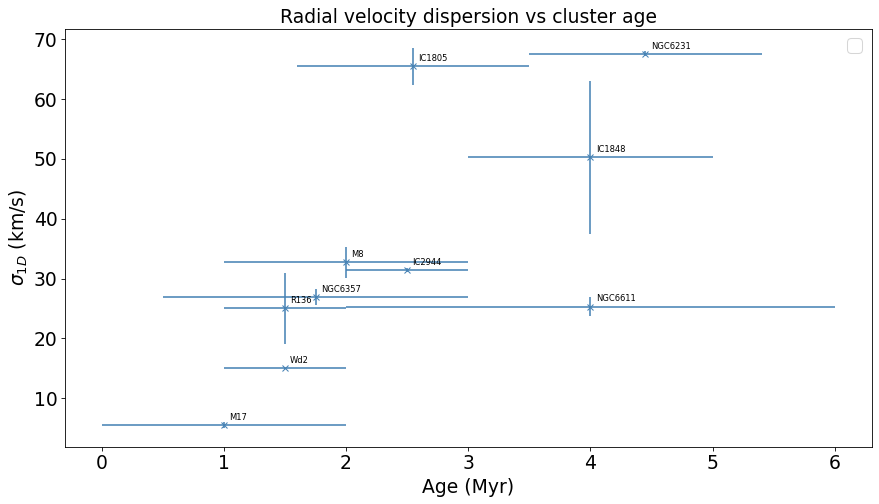

In [6]:
fig, ax = plt.subplots(1,1, figsize=(12,7))
ax.errorbar(age, s1D,xerr=age_err, yerr=s1D_err, marker='x', color='steelblue', ls='None')

for i, name in enumerate(data['cluster']):
    ax.annotate(name, (age.iloc[i], s1D.iloc[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

# ax.set_xlabel(r'age')
# ax.set_ylabel(r'sigma1D')
ax.set_xlabel('Age (Myr)')
ax.set_ylabel(r'$\sigma_{1D}$ (km/s)')
ax.set_title('Radial velocity dispersion vs cluster age')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
X = np.vander(age, 2, increasing=True)
wlsModel = sm.WLS(s1D, X, weights=1/s1D_err**2)
wlsFit = wlsModel.fit()
t0,t1 = wlsFit.params
e0,e1 = wlsFit.bse
wlsFit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                sigma1D   R-squared:                       0.968
Model:                            WLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     243.2
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.85e-07
Time:                        06:56:21   Log-Likelihood:                -36.760
No. Observations:                  10   AIC:                             77.52
Df Residuals:                       8   BIC:                             78.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.8752      2.072     -5.248      0.001     -15.654      -6.097
x1            17.2237      1.104     15.595      0.000      14.677      19.771
==============================================================================
Omnibus:                       12.593   Durbin-Watson:                   2.125
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                5.927
Skew:                          -1.536   Prob(JB):                       0.0516
Kurtosis:                       5.187   Cond. No.                         6.18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

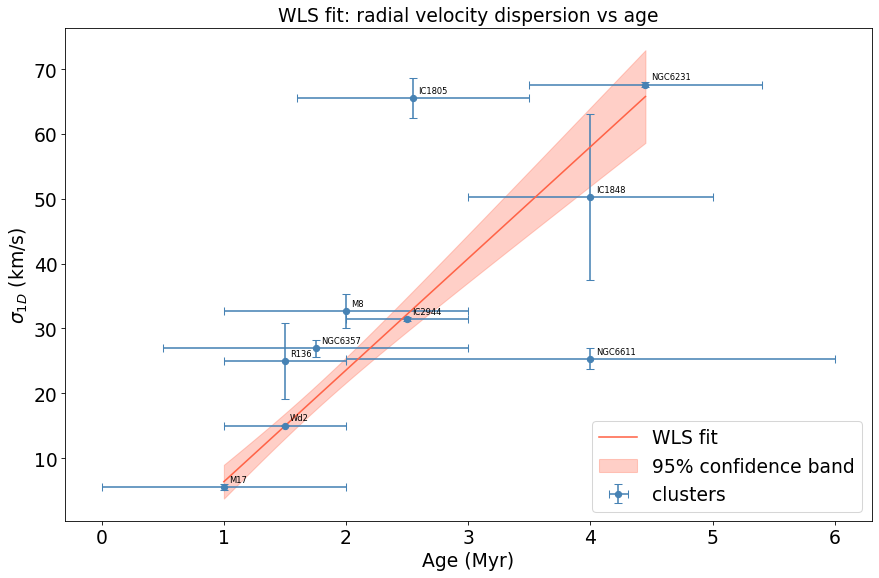

In [8]:
age_range = np.linspace(age.min(), age.max(), 200)
X_pred = sm.add_constant(age_range)

pred = wlsFit.get_prediction(X_pred)
pred_df = pred.summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 8))

ax.errorbar(age, s1D,
            xerr=age_err, yerr=s1D_err,
            fmt='o', color='steelblue', capsize=4, label='clusters')

for i, name in enumerate(data['cluster']):
    ax.annotate(name, (age.iloc[i], s1D.iloc[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.plot(age_range, pred_df['mean'], color='tomato', label='WLS fit')
ax.fill_between(age_range, pred_df['mean_ci_lower'], pred_df['mean_ci_upper'],
                alpha=0.3, color='tomato', label='95% confidence band')

ax.set_xlabel('Age (Myr)')
ax.set_ylabel(r'$\sigma_{1D}$ (km/s)')
ax.set_title('WLS fit: radial velocity dispersion vs age')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
print(data[['cluster', 'sigma1D', 'sigma1D_err']].to_string())

   cluster  sigma1D  sigma1D_err
0   IC1805     65.5          3.1
1   IC1848     50.3         12.8
2   IC2944     31.4          0.3
3  NGC6231     67.6          0.4
4  NGC6611     25.3          1.6
5      Wd2     15.0          0.1
6      M17      5.5          0.5
7       M8     32.7          2.6
8  NGC6357     26.9          1.3
9     R136     25.0          5.9


## WLS fit: age vs σ₁D

The scatter plot shows a general positive trend between age and σ₁D, consistent with 
the binary inspiral hypothesis. Two clusters sit noticeably above the rest: IC1805 
(σ₁D = 65.5 ± 3.1 km/s) and NGC6231 (σ₁D = 67.6 ± 0.4 km/s).

The WLS fit gives a slope of **17.22 ± 1.10 km/s/Myr** and intercept of 
**-10.9 ± 2.1 km/s** (both significant at 1% level, p < 0.001). Given their small 
uncertainties, IC1805 and NGC6231 carry large weights and likely pull the slope 
upward, robust regression is applied next to assess this.

### Apply a robust regression technique to the data. 

In [9]:
# Robust Linear Model - same design matrix and y as before
rlm_fit = sm.RLM(s1D, X).fit()
print(rlm_fit.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:                sigma1D   No. Observations:                   10
Model:                            RLM   Df Residuals:                        8
Method:                          IRLS   Df Model:                            1
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Mon, 16 Mar 2026                                         
Time:                        06:56:24                                         
No. Iterations:                    12                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0592      7.617      0.008      0.9

In [ ]:
# Plot both fits together for comparison
fig, ax = plt.subplots(figsize=(12, 9))

ax.errorbar(age, s1D,
            xerr=age_err, yerr=s1D_err,
            fmt='o', color='steelblue', capsize=4, label='clusters')

for i, name in enumerate(data['cluster']):
    ax.annotate(name, (age.iloc[i], s1D.iloc[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.plot(age_range, wlsFit.predict(X_pred), color='tomato', label='WLS fit')
ax.plot(age_range, rlm_fit.predict(X_pred), color='green', linestyle='--', label='Robust fit')

ax.set_xlabel('Age (Myr)')
ax.set_ylabel(r'$\sigma_{1D}$ (km/s)')
ax.set_title('WLS vs Robust regression')
ax.legend()
plt.tight_layout()
plt.show()

### Do you see significant differences on the slope of the relationships compared to your results using weighted least-squares?

The robust fit gives a slope of **13.58 ± 2.74 km/s/Myr** where it is ~21% lower than WLS. 
The positive trend is present in both methods, but the difference confirms that 
IC1805 and NGC6231 have disproportionate influence in WLS.

## Nonlinear fit: Pmin vs age

The dataset also contains the minimum orbital period P_min for each cluster. 
If the binary inspiral hypothesis is correct, P_min should decrease with age 
as binaries gradually spiral inward, here we verify this visually before attempting a fit.

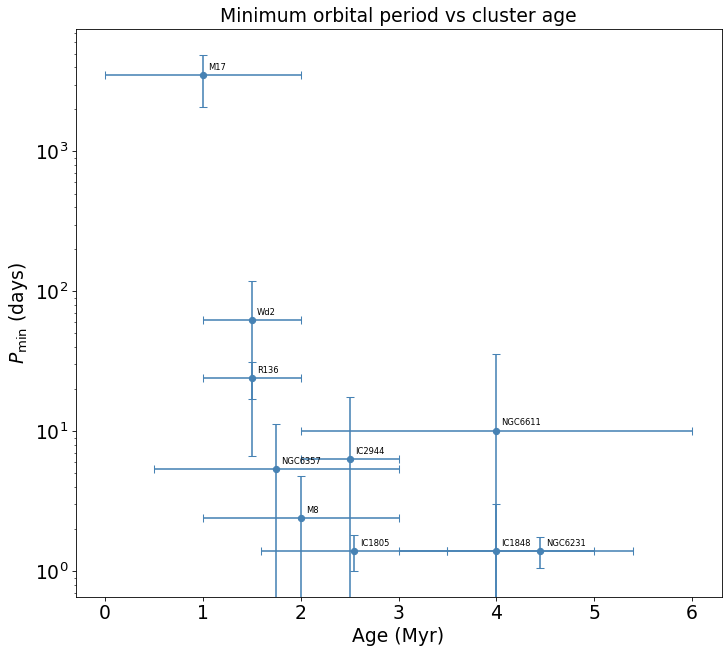

In [11]:
# Compute symmetric Pmin uncertainty
data['Pmin_err'] = 0.5 * (data['Pmin_errlow'] + data['Pmin_errhigh'])

fig, ax = plt.subplots(figsize=(10, 9))

ax.errorbar(age, data['Pmin'],
            xerr=age_err, yerr=data['Pmin_err'],
            fmt='o', color='steelblue', capsize=4)

for i, name in enumerate(data['cluster']):
    ax.annotate(name, (age.iloc[i], data['Pmin'].iloc[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_yscale('log')
ax.set_xlabel('Age (Myr)')
ax.set_ylabel(r'$P_{\min}$ (days)')
ax.set_title(r'Minimum orbital period vs cluster age')
plt.tight_layout()
plt.show()

The plot confirms the expected trend: P_min decreases sharply with age, consistent 
with the binary inspiral hypothesis. A log scale is used on the y-axis since M17 
(P_min ~ 3500 days) would otherwise dominate the plot

In [15]:
#nonlinear fit attempt
def pmin_model(t, theta0, theta1):
    return 1.4 + theta0 * np.exp(-t / theta1)

try:
    popt, pcov = curve_fit(pmin_model, age, data['Pmin'],
                           sigma=data['Pmin_err'], absolute_sigma=True)
    print(f"theta0 = {popt[0]:.2f} days")
    print(f"theta1 = {popt[1]:.2f} Myr")
    print(f"Uncertainties: sigma_theta0 = {np.sqrt(pcov[0,0]):.2f}, "
          f"sigma_theta1 = {np.sqrt(pcov[1,1]):.2f}")
except Exception as e:
    print("Fitting failed:", e)

theta0 = 72907475.51 days
theta1 = 0.10 Myr
Uncertainties: sigma_theta0 = 98683016.91, sigma_theta1 = 0.01


### Nonlinear regression
We attempted to fit the model
$$
P_{\min} = 1.4 + \theta_0 e^{-t/\theta_1}
$$
using `curve_fit`. Although the optimizer reports convergence, the parameters are 
unphysical (θ₀ ~ 7×10⁷ days, θ₁ ~ 0.1 Myr) and their uncertainties exceed the 
values themselves. This is likely because P_min spans three orders of magnitude, 
causing the fit to be driven by only a few clusters. We therefore attempt a fit 
in log space as a possible remedy.

In [19]:
# Attempt 2: fit in log space to reduce dynamic range
def log_pmin_model(t, theta0, theta1):
    return np.log(1.4 + theta0 * np.exp(-t / theta1))

popt2, pcov2 = curve_fit(log_pmin_model, age, np.log(data['Pmin']),
                          p0=[3500, 1.0])
print(f"theta0 = {popt2[0]:.2f} days, theta1 = {popt2[1]:.2f} Myr")

theta0 = 23548577.31 days, theta1 = 0.11 Myr


/home/agungnegara/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log



still failed, the log space fit also fails to produce reliable parameters. With only 10 data points 
and large uncertainties on most $P_{\min}$ values, a reliable constraint on both 
parameters simultaneously is not feasible with this dataset.

conclusion: not feasible with this dataset